# Treinamento da BearingCNN no Dataset XJTU-SY

**Projeto:** Diagnóstico de Falhas em Rolamentos Industriais via CWT + CNN  
**Dataset:** Xi'an Jiaotong University (XJTU-SY — 25.6 kHz, Ensaio Run-to-Failure)  
**Classes:** 3 Classes (`normal`, `inner_race`, `outer_race`)  
**Objetivo:** Treinar do zero a arquitetura convolucional própria `BearingCNN` (com *Global Average Pooling*) sobre escalogramas CWT gerados a partir dos sinais de vibração do XJTU-SY.

---


## 1. Importação de Módulos e Configurações


In [2]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name in ['1_cwru', '2_paderborn', '3_cross_domain', '4_order_tracking', '5_xjtu'] else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

from src.config import RANDOM_SEED, XJTU_PROCESSED_DIR, NUM_EPOCHS, LEARNING_RATE
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

from src.cnn_processor import train_and_evaluate_bearing_cnn, get_data_loaders
from src.visualization import plot_training_curves, plot_confusion_matrix


## 2. Treinamento da BearingCNN com Checkpointing Automático


In [3]:
# Treinamento de 10 épocas da BearingCNN com salvamento automático do melhor modelo (val_loss)
resultado_cnn = train_and_evaluate_bearing_cnn(
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    data_dir=XJTU_PROCESSED_DIR,
    checkpoint_name="checkpoint_xjtu_bearing_cnn_best.pth"
)


[INFO] EXPERIMENTO BEARING CNN (PRÓPRIA) | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.6985 - Acc: 71.84% | Val Loss: 0.5315 - Acc: 82.53% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.4179 - Acc: 88.07% | Val Loss: 0.3999 - Acc: 82.26% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.2402 - Acc: 98.52% | Val Loss: 0.2125 - Acc: 95.43% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.1291 - Acc: 99.54% | Val Loss: 0.1024 - Acc: 98.92% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0717 - Acc: 99.90% | Val Loss: 0.0811 - Acc: 98.39% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0458 - Acc: 99.80% | Val Loss: 0.0813 - Acc: 97.58% 
Época [07/10] | Treino Loss: 0.0377 - Acc: 99.95% | Val Loss: 0.0442 - Acc: 99.46% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0285 - Acc: 99.90% | Val Loss: 0.01

## 3. Curvas de Aprendizado (Loss e Acurácia)


[INFO] Figura salva em: ../../docs/images/training_curves_xjtu_bearing_cnn.png


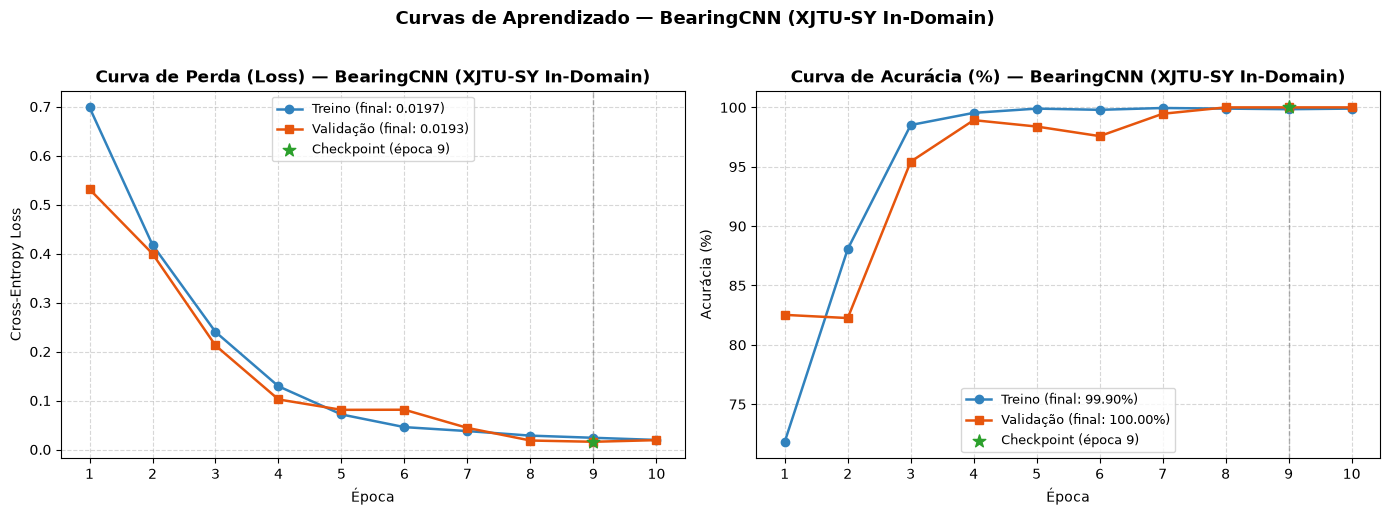

In [4]:
plot_training_curves(
    history=resultado_cnn["history"],
    model_name="BearingCNN (XJTU-SY In-Domain)",
    save_path="../../docs/images/training_curves_xjtu_bearing_cnn.png"
)


## 4. Matriz de Confusão e Relatório de Classificação no Conjunto de Teste


 RELATÓRIO DE CLASSIFICAÇÃO NO TESTE — BEARINGCNN (XJTU-SY)
              precision    recall  f1-score   support

  inner_race     1.0000    1.0000    1.0000       155
      normal     1.0000    1.0000    1.0000       155
  outer_race     1.0000    1.0000    1.0000       155

    accuracy                         1.0000       465
   macro avg     1.0000    1.0000    1.0000       465
weighted avg     1.0000    1.0000    1.0000       465

[INFO] Figura salva em: ../../docs/images/confusion_matrix_xjtu_bearing_cnn.png


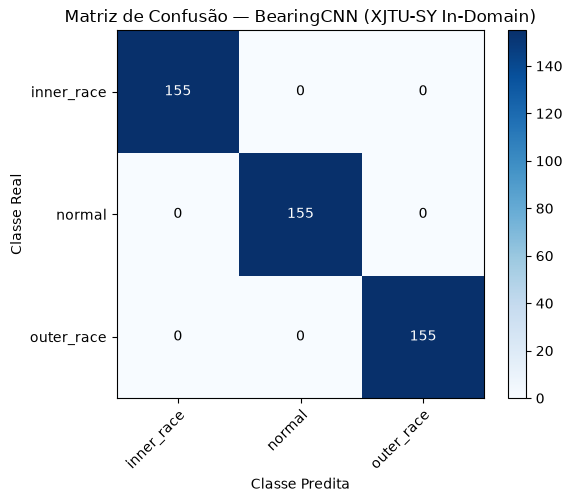

In [5]:
y_true = resultado_cnn["test_labels"]
y_pred = resultado_cnn["test_preds"]
class_names = resultado_cnn["classes"]

print("=" * 65)
print(" RELATÓRIO DE CLASSIFICAÇÃO NO TESTE — BEARINGCNN (XJTU-SY)")
print("=" * 65)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

plot_confusion_matrix(
    res=resultado_cnn,
    model_name="BearingCNN (XJTU-SY In-Domain)",
    save_path="../../docs/images/confusion_matrix_xjtu_bearing_cnn.png"
)
